# Toy Model for Paper Diffusion Models Memorize in Training -- and Generalize in Inference

# 1. Setup
<a id='setup'></a>
Ensure you have the following packages installed in your current environment and start exploring the notebook:
- Numpy
- Matplotlib
- tqdm


In [ ]:


from plots.toy_model.toy_utils import *

plt.style.use('default')

%load_ext autoreload
%autoreload 2

## Flow field

Delta: 0.0


  0%|          | 0/3 [00:00<?, ?it/s]/home/tikai103/diffusion_overfit/plots/toy_utils.py:219: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=1)
100%|██████████| 3/3 [00:01<00:00,  1.92it/s]


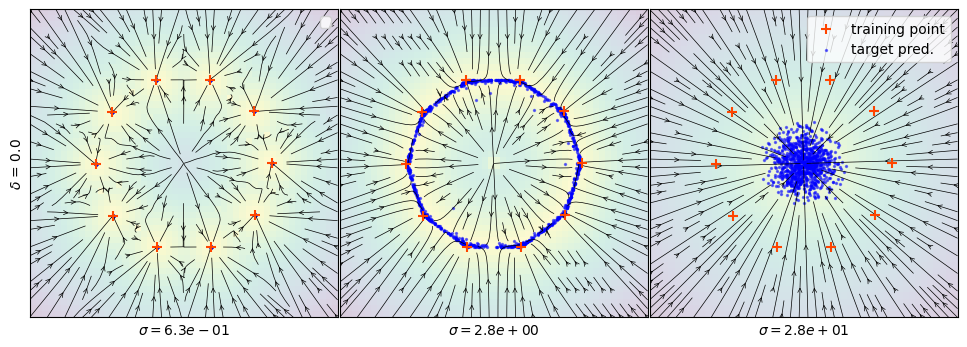

In [16]:
random_data = False
mode = 'flow'  # 'flow', 'displacement'

sigma_idx = [14, 20, 32]  # which sigmas to plot
all_deltas = np.array([0e-2])  # optimal predictor
N = 10 if not random_data else 20
plot_points = N

plt.figure(figsize=(4*len(sigma_idx), 4*len(all_deltas)))

data_str, N, data, data_labels, data_split = prepare_data(random_data, N=N, split=False, offset=1e-3)

scale = 10
data = data * scale
window_size = 1.75 * scale
all_deltas = all_deltas * scale

# Sampler settings 
dim = data.shape[1]
num_steps, sigma_min, sigma_max, rho = 40, 2e-3, 80, 7  # Number of steps, min noise level, max noise level, sampler curvature


plt.subplots_adjust(hspace=0, wspace=0)
plot_counter = 1
for i, delta in enumerate(all_deltas):
    print(f"Delta: {delta}")
    _, plot_counter, _ = model_and_metric(data, data_split, data_labels, num_steps, sigma_min, sigma_max, rho, delta, window_size, 
                                          samples_per_point=100, 
                                          sigma_idx=sigma_idx, 
                                          plot_counter=plot_counter, 
                                          plot=True, 
                                          contours=True, 
                                          threshold=False, 
                                          plot_points=plot_points, 
                                          plot_samples_per_point=100, 
                                          n_rows=len(all_deltas),
                                          plot_sigma_idx=sigma_idx,
                                          mode=mode, 
                                          scale=scale,
                                          # save_folder=f"/home/tikai103/diffusion_overfit/plots/figs/eccv2026/toy_model/paper_plots/{data_str}/{mode}_d{delta:.1e}",
                                          )

plt.legend()
plt.show()
plt.close()

Delta: 2.0


100%|██████████| 1/1 [00:00<00:00,  8.12it/s]


Delta: 1.6


100%|██████████| 1/1 [00:00<00:00, 10.42it/s]


Delta: 1.2


100%|██████████| 1/1 [00:00<00:00, 10.36it/s]


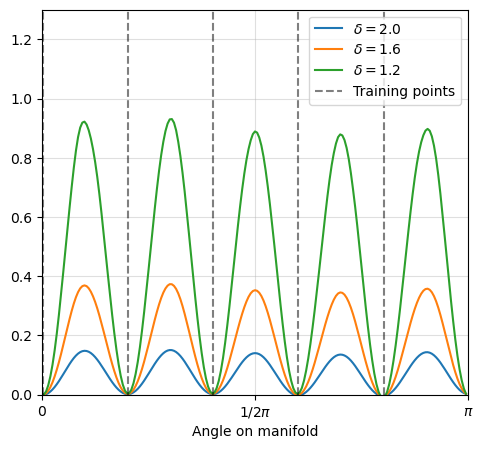

In [130]:
random_data = False
mode = 'error'

plot_points = 0
sigma_idx = [16]  # which sigmas to plot
all_deltas = np.array([20e-2, 16e-2, 12e-2])
N = 10
plt.figure(figsize=(5.5,5))
    
data_str, N, data, data_labels, data_split = prepare_data(random_data, N=N, split=False, offset=1e-3)

scale = 10
data = data * scale
window_size = 1.5 * scale
all_deltas = all_deltas * scale

# Sampler settings 
dim = data.shape[1]
num_steps, sigma_min, sigma_max, rho = 40, 2e-3, 80, 7  # Number of steps, min noise level, max noise level, sampler curvature


plt.subplots_adjust(hspace=0, wspace=0)
plot_counter = 1
for i, delta in enumerate(all_deltas):
    print(f"Delta: {delta}")
    _, plot_counter, t_steps = model_and_metric(data, data_split, data_labels, num_steps, sigma_min, sigma_max, rho, delta, window_size, 
                                                samples_per_point=100, 
                                                sigma_idx=sigma_idx, 
                                                plot_counter=plot_counter, 
                                                plot=True, 
                                                contours=True, 
                                                threshold=False, 
                                                plot_points=plot_points, 
                                                plot_samples_per_point=100, 
                                                n_rows=len(all_deltas),
                                                plot_sigma_idx=sigma_idx,
                                                mode=mode, 
                                                scale=scale,
                                                )
    
training_angles = np.arctan2(data[1:,1], data[1:,0]) + np.pi  # in range (0,2pi)
plt.vlines(training_angles, 0, 10, color='black', linestyle='--', label='Training points', alpha=0.5)
plt.legend()
plt.ylim([0, 1.3]) if not random_data else plt.ylim([0,6])
# save_folder = f"/home/tikai103/diffusion_overfit/plots/figs/eccv2026/toy_model/paper_plots/{data_str}/"
os.makedirs(save_folder, exist_ok=True)
plt.savefig(os.path.join(save_folder, f"{mode}_s{t_steps[sigma_idx].item():.1e}.png"), dpi=200, bbox_inches='tight')
plt.show()
plt.close()

## FD

100%|██████████| 40/40 [00:01<00:00, 25.25it/s]


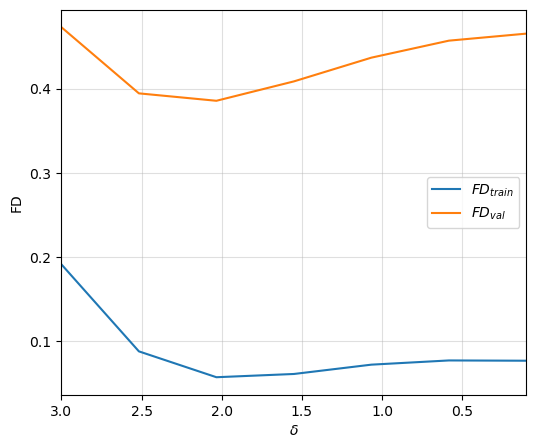

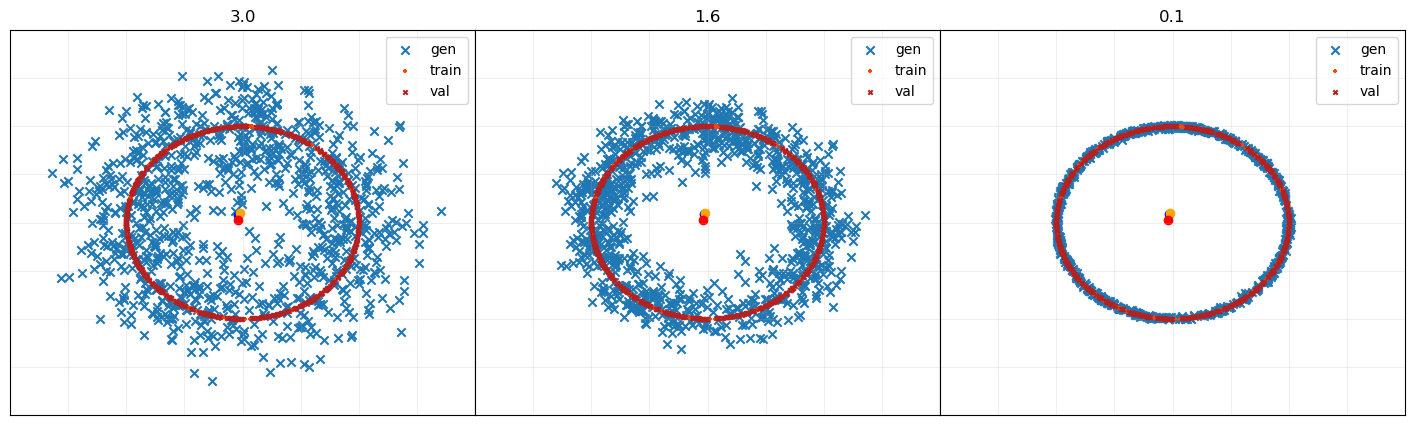

In [3]:
random_data = True
data_str, N, data, data_labels, data_split = prepare_data(random_data, N=1000, seed=2)
all_deltas =  np.linspace(30e-2, 1e-2, 7, endpoint=True) # random: [1.8e-1, 1.3e-1, 7e-2]  symm: [1.2e-1, 1e-1, 8e-2]

scale = 10
data = data * scale
window_size = 2 * scale
all_deltas = all_deltas * scale

# Deltas to plot
plot_deltas_idx = [0, len(all_deltas)//2, len(all_deltas)-1]
plot_deltas = all_deltas[plot_deltas_idx]
D = data.shape[1]

# Sampler settings 
dim = data.shape[1]
num_steps, sigma_min, sigma_max, rho = 40, 2e-3, 80, 7  # Number of steps, min noise level, max noise level, sampler curvature
num_generated = 1000

all_fd_mu_train, all_fd_cov_train = np.zeros((len(all_deltas),)), np.zeros((len(all_deltas),))
all_fd_mu_val, all_fd_cov_val = np.zeros((len(all_deltas),)), np.zeros((len(all_deltas),))
plot_endpoints = np.zeros((len(all_deltas), num_generated, D))
plot_mu_gen = np.zeros((len(plot_deltas), D))
plot_mu_train = np.zeros((len(plot_deltas), D))
plot_mu_val = np.zeros((len(plot_deltas), D))
c = 0  # plot counter
for i, delta in enumerate(all_deltas):
    # Toy Model settings
    model = ToyModel(data=data[data_split], 
                     data_labels=data_labels[data_split], 
                     num_steps=num_steps, 
                     sigma_min=sigma_min, 
                     sigma_max=sigma_max, 
                     rho=rho, 
                     model_kwargs={'delta': delta, 'cond': False},  # positive network
                     heun=False)
    
    # Simulate and plot
    trajects = model.run(x_labels=None,    # CLass labels for trajectories, None = random
                         n=num_generated,  # number of trajectories
                         init='random',    # Initialization mode, 'random' or 'sphere')[0]  # (n,num_steps,D)
                        )[0]  # (n, num_steps, D)
    gen_samples = trajects[:,-1]  # trajectory endpoints

    # Compute FDs
    mu_gen, cov_gen = frechet_stats(gen_samples)
    mu_train, cov_train = frechet_stats(data[data_split])
    mu_val, cov_val = frechet_stats(data[~data_split])
    if i in plot_deltas_idx:
        plot_endpoints[c] = gen_samples
        plot_mu_gen[c] = mu_gen
        plot_mu_train[c] = mu_train
        plot_mu_val[c] = mu_val
        c += 1
        
    all_fd_mu_train[i], all_fd_cov_train[i] = frechet_distance(mu_gen, cov_gen, mu_train, cov_train, eps=1e-12)
    all_fd_mu_val[i], all_fd_cov_val[i] = frechet_distance(mu_gen, cov_gen, mu_val, cov_val, eps=1e-12)

# Plot FD vs model error
plt.figure(figsize=(6,5))
# plt.plot(all_deltas, all_fd_mu_train, label='$mu_{{train}}$', linestyle='--', c='C0')
# plt.plot(all_deltas, all_fd_cov_train, label='$cov_{{train}}$', linestyle=':', c='C0')
plt.plot(all_deltas, all_fd_mu_train + all_fd_cov_train, label='$FD_{{train}}$', c='C0')
# plt.plot(all_deltas, all_fd_mu_val, label='$mu_{{val}}$', linestyle='--', c='C1')
# plt.plot(all_deltas, all_fd_cov_val, label='$cov_{{val}}$', linestyle=':', c='C1')
plt.plot(all_deltas, all_fd_mu_val + all_fd_cov_val, label='$FD_{{val}}$', c='C1')
plt.legend()
plt.grid(alpha=0.4)
plt.xlim([all_deltas[0], all_deltas[-1]])
plt.xlabel('$\delta$')
plt.ylabel('FD')
plt.show()
plt.close()

# Visualize

plt.figure(figsize=(6*len(plot_deltas),5))
plt.subplots_adjust(hspace=0, wspace=0)
for c, delta in enumerate(plot_deltas):
    plt.subplot(1,len(plot_deltas), c+1)
    plt.scatter(plot_endpoints[c,:,0], plot_endpoints[c,:,1], label='gen', marker='x')
    setup_plot(window_size, data, data_split, s=10)
    plt.legend()
    plt.title(f"{delta:.1f}")
    plt.scatter(plot_mu_gen[c,0], plot_mu_gen[c,1], c='blue')
    plt.scatter(plot_mu_train[c,0], plot_mu_train[c,1], c='orange')
    plt.scatter(plot_mu_val[c,0], plot_mu_val[c,1], c='red')
plt.show()
plt.close()

## Guidance

100%|██████████| 120/120 [00:00<00:00, 183.36it/s]


<Figure size 600x500 with 0 Axes>

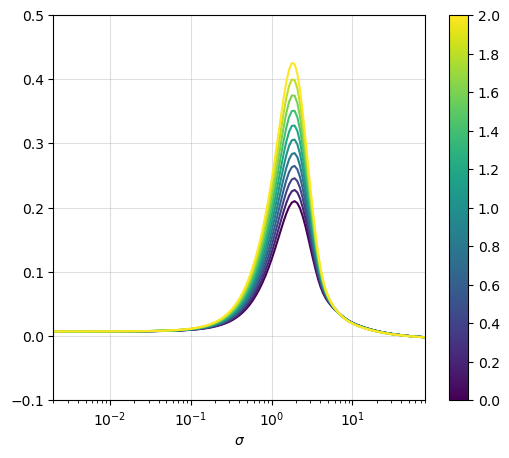

In [5]:
random_data = True
data_str, N, data, data_labels, data_split = prepare_data(random_data)

scale = 10
data = data * scale
window_size = 2 * scale

delta_pos = 18e-2 * scale
delta_neg = 22e-2 * scale
guid_weights = np.arange(0, 2.2, 0.2).tolist()

# Sampler settings 
dim = data.shape[1]
num_steps, sigma_min, sigma_max, rho = 120, 2e-3, 80, 7  # Number of steps, min noise level, max noise level, sampler curvature

all_errors = np.zeros((len(guid_weights), num_steps))
for i, g_weight in enumerate(guid_weights):
    relative_error, _, t_steps = model_and_metric(data, data_split, data_labels, num_steps, sigma_min, sigma_max, rho, delta_pos, window_size, 
                                                  guid_weight=g_weight, delta_neg=delta_neg,
                                                  samples_per_point=50, sigma_idx=np.arange(num_steps), plot=False)
    all_errors[i] = relative_error


# Make generalization gap plot
plt.figure(figsize=(6,5))
def fmt(x, pos):
    return f'{x:.1f}'  # Format tick labels

gen_gap_plot(t_steps, 
             all_errors, 
             color_range=guid_weights, 
             cbar_ticks=guid_weights, 
             ylim=[-0.1, 1.0] if not random_data else [-0.1, 0.5], 
             fmt=fmt, 
             cmap='viridis',
             save_as=f"/home/tikai103/diffusion_overfit/plots/figs/eccv2026/toy_model/paper_plots/{data_str}/{data_str}_toy_l2_guidance.png",
            )

## Model error delta

100%|██████████| 120/120 [00:00<00:00, 1120.68it/s]


<Figure size 600x500 with 0 Axes>

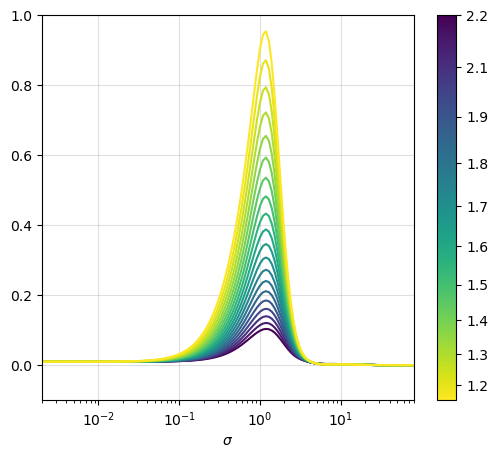

In [14]:
random_data = False
data_str, N, data, data_labels, data_split = prepare_data(random_data)
all_deltas =  np.linspace(22e-2, 12e-2, 11, endpoint=True) # random: [1.8e-1, 1.3e-1, 7e-2]  symm: [1.2e-1, 1e-1, 8e-2]

scale = 10
data = data * scale
window_size = 2 * scale
all_deltas = all_deltas * scale

# Sampler settings 
dim = data.shape[1]
num_steps, sigma_min, sigma_max, rho = 120, 2e-3, 80, 7  # Number of steps, min noise level, max noise level, sampler curvature

all_errors = np.zeros((len(all_deltas), num_steps))
for i, delta in enumerate(all_deltas):
    relative_error, _, t_steps = model_and_metric(data, data_split, data_labels, num_steps, sigma_min, sigma_max, rho, delta, window_size, 
                                                  samples_per_point=50, sigma_idx=np.arange(num_steps), plot=False)
    all_errors[i] = relative_error

# Make generalization gap plot
plt.figure(figsize=(6,5))
def fmt(x, pos):
    return f'{x:.1f}'  # Format tick labels

gen_gap_plot(t_steps, 
             all_errors, 
             color_range=all_deltas, 
             cbar_ticks=all_deltas[::2], 
             ylim=[-0.1, 1.0] if not random_data else [-0.1, 0.5], 
             fmt=fmt, 
             save_as=f"/home/tikai103/diffusion_overfit/plots/figs/eccv2026/toy_model/paper_plots/{data_str}/{data_str}_toy_l2.png",
            )

## Data density

100%|██████████| 120/120 [00:00<00:00, 562.11it/s]


<Figure size 48000x400 with 0 Axes>

<Figure size 400x3200 with 0 Axes>

<Figure size 400x3200 with 0 Axes>

<Figure size 400x3200 with 0 Axes>

<Figure size 400x3200 with 0 Axes>

<Figure size 400x3200 with 0 Axes>

<Figure size 400x3200 with 0 Axes>

<Figure size 400x3200 with 0 Axes>

<Figure size 600x500 with 0 Axes>

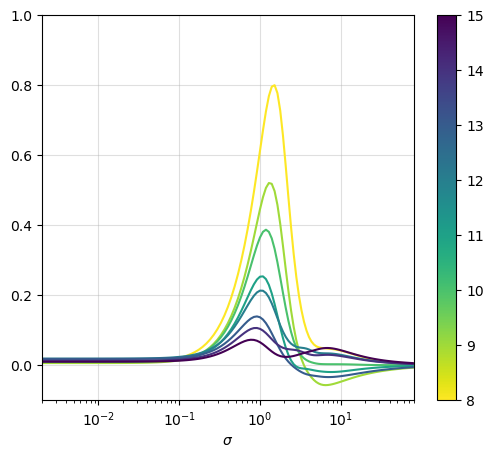

In [121]:
random_data = False

# Sampler settings 
num_steps, sigma_min, sigma_max, rho = 120, 2e-3, 80, 7  # Number of steps, min noise level, max noise level, sampler curvature
sigma_idx = np.arange(num_steps)

all_N = np.linspace(16, 30, 8) if not random_data else np.linspace(20, 60, 5)  #np.array([36, 48, 60, 90, 120])
all_errors = np.zeros((len(all_N), num_steps))
all_deltas = [12e-2]

scale = 10
delta =  16e-2 * scale
window_size = 2 * scale

plt.figure(figsize=(4*len(sigma_idx), 4*len(all_deltas)))
plt.subplots_adjust(hspace=0, wspace=0)
plot_counter = 1

for i, N in enumerate(all_N):
    data_str, N, data, data_labels, data_split = prepare_data(random_data, N=int(N), seed=2)
    
    dim = data.shape[1]
    
    data = data * scale
    plt.figure(figsize=(4,4*len(all_N)))
    relative_error, _, t_steps = model_and_metric(data, data_split, data_labels, num_steps, sigma_min, sigma_max, rho, delta, window_size, 
                                                  samples_per_point=50, sigma_idx=sigma_idx, plot=False,
                                                  plot_points=N, 
                                                  plot_samples_per_point=50, 
                                                  n_rows=len(all_N),
                                                  plot_sigma_idx=np.array([110]),
                                                  plot_counter=1)
    all_errors[i] = relative_error
plt.close()

# Make generalization gap plot
plt.figure(figsize=(6,5))
def fmt(x, pos):
    return f'{x:.0f}'  # Format tick labels

gen_gap_plot(t_steps, 
             all_errors, 
             color_range=all_N//2, 
             cbar_ticks=all_N//2, 
             ylim=[-0.1, 1.0] if not random_data else [-0.05, 0.5], 
             fmt=fmt, 
             save_as=f"/home/tikai103/diffusion_overfit/plots/figs/eccv2026/toy_model/paper_plots/{data_str}/{data_str}_toy_l2_density.png",
            )
plt.show()
plt.close()

Delta = 0.00


100%|██████████| 40/40 [00:00<00:00, 2796.39it/s]


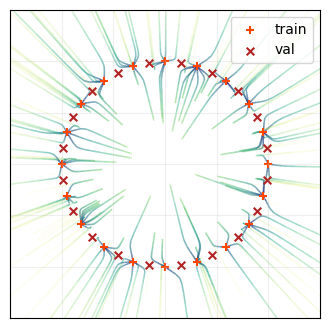

In [273]:
random_data = False
data_str, all_deltas, sigma_idx, N, data, data_labels, data_split = prepare_data(random_data, N=40, seed=1)
all_deltas = np.array([0])

scale = 1
data = data * scale
window_size = 1.5 * scale
all_deltas = all_deltas * scale

# Sampler settings 
dim = data.shape[1]
num_steps, sigma_min, sigma_max, rho = 40, 2e-3, 80, 7  # Number of steps, min noise level, max noise level, sampler curvature

for i, delta in enumerate(all_deltas):
    print(f"Delta = {delta:.2f}")
    # Toy Model settings
    model = ToyModel(data=data[data_split], 
                     data_labels=data_labels[data_split], 
                     num_steps=num_steps, 
                     sigma_min=sigma_min, 
                     sigma_max=sigma_max, 
                     rho=rho, 
                     model_kwargs={'delta': delta, 'cond': False},  # positive network
                     heun=False)
    
    # Simulate and plot
    n = 150
    out = simulate_trajectories(model=model, 
                                x_labels=None,                     # CLass labels for trajectories, None = random
                                n=n,                             # number of trajectories
                                m=n,                             # how many to plot
                                init='random',                     # Initialization mode, 'random' or 'sphere'
                                delta=delta,                       # For ylabel
                                data=data,
                                data_split=data_split,
                                window_size=window_size,
                                full_row=False,
                                save_as=None)                      # Path to save png in
    
del num_steps, sigma_min, sigma_max, rho, model, out

### Animation

In [21]:
random_data = True
data_str = 'random' if random_data else 'symmetric'

if not random_data:
    # Symmetric on circle
    N = 20
    u = np.linspace(0,1,N, endpoint=False)          # uniform in [0, 1]
    theta = 2 * np.pi * u          # angle
    data = np.stack([np.cos(theta), np.sin(theta)], axis=1)
    data_labels = np.arange(N)  # One label per datapoint for now
    data_split = np.zeros(N, dtype=bool)
    data_split[::2] = 1  # 1 = train, 0 = validation
else:
    # Random on Circle
    N = 40
    u = np.random.rand(N)          # uniform in [0, 1]
    theta = 2 * np.pi * u          # angle
    data = np.stack([np.cos(theta), np.sin(theta)], axis=1)
    data_labels = np.arange(N)  # One label per datapoint for now
    data_split = np.array([0] * (N // 2) + [1] * (N // 2), dtype=bool)  # 1 = train, 0 = validation

# Sampler settings 
dim = data.shape[1]
num_steps, sigma_min, sigma_max, rho = 40, 2e-3, 80, 7  # Number of steps, min noise level, max noise level, sampler curvature

all_deltas = [2e-1, 1e-1, 5e-2]
all_errors = np.zeros((len(all_deltas), num_steps))
for i, delta in enumerate(all_deltas):
    # Toy Model settings
    model = ToyModel(data=data[data_split], 
                     data_labels=data_labels[data_split], 
                     num_steps=num_steps, 
                     sigma_min=sigma_min, 
                     sigma_max=sigma_max, 
                     rho=rho, 
                     model_kwargs={'delta': delta, 'cond': False},  # positive network
                     precond=False,
                     heun=False)
    
    # Compute L2 denoising error
    t_steps = model.t_schedule()[:-1][::-1]
    save_folder = f"/home/tikai103/diffusion_overfit/plots/figs/eccv2026/toy_model/{data_str}/error_region_d{delta:.1e}"
    os.makedirs(save_folder, exist_ok=True)
    # relative_error, plot_counter = l2_metric(model, 
    #                                          model.model_kwargs['delta'], 
    #                                          data, 
    #                                          data_split, 
    #                                          t_steps, 
    #                                          samples_per_point=100,  # How many samples to run per datapoint
    #                                          x_labels=None, 
    #                                          cond=False,
    #                                          plot=True,
    #                                          plot_points=0,  # How many datapoints to include in the plot
    #                                          plot_samples_per_point=100,  # How many samples per datapoint to include in the plot
    #                                          plot_sigmas=t_steps,
    #                                          plot_counter=plot_counter,
    #                                          n_rows=len(all_deltas),  # How many samples per datapoint to show in the plot
    #                                          draw_displacement=True,
    #                                          save_folder=save_folder,
    #                                          )

  2%|▎         | 1/40 [00:00<00:08,  4.43it/s]

  5%|▌         | 2/40 [00:00<00:08,  4.42it/s]

  8%|▊         | 3/40 [00:00<00:08,  4.37it/s]

 10%|█         | 4/40 [00:00<00:08,  4.37it/s]

 12%|█▎        | 5/40 [00:01<00:08,  4.34it/s]

...

 15%|█▌        | 6/40 [00:01<00:07,  4.29it/s]

 18%|█▊        | 7/40 [00:01<00:07,  4.28it/s]

 20%|██        | 8/40 [00:01<00:07,  4.22it/s]

 22%|██▎       | 9/40 [00:02<00:07,  4.27it/s]

100%|██████████| 40/40 [00:09<00:00,  4.26it/s]


In [24]:
# Animations for multiuple deltas next to each other 

from PIL import Image
import imageio
import numpy as np

# Example setup
frame_paths = [
    f"/home/tikai103/diffusion_overfit/plots/figs/eccv2026/toy_model/{data_str}/error_region_d{delta:.1e}/s{sigma:.1e}.png"
    for sigma in t_steps
    for delta in all_deltas
]

# Step 1: Loop over sigma frames
stitched_frames = []
for i, sigma in enumerate(t_steps[::-1]):
    imgs = []
    for delta in all_deltas:
        path = f"/home/tikai103/diffusion_overfit/plots/figs/eccv2026/toy_model/{data_str}/error_region_d{delta:.1e}/s{sigma:.1e}.png"
        img = Image.open(path)
        imgs.append(img)
    # Step 2: Stitch horizontally
    widths, heights = zip(*(im.size for im in imgs))
    total_width = sum(widths)
    max_height = max(heights)
    new_im = Image.new('RGBA', (total_width, max_height))
    x_offset = 0
    for im in imgs:
        new_im.paste(im, (x_offset, 0))
        x_offset += im.width
    stitched_frames.append(new_im)

# Step 3: Save as a single animated GIF or MP4
stitched_frames[0].save(
    f"figs/eccv2026/toy_model/{data_str}/toy_model_deltas.gif",
    save_all=True,
    append_images=stitched_frames[1:],
    duration=150,  # milliseconds per frame
    loop=0
)
imageio.mimsave(f"figs/eccv2026/toy_model/{data_str}/toy_model_deltas.mp4", [np.array(f) for f in stitched_frames], fps=8)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (2097, 695) to (2112, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [9]:
from IPython.display import HTML

HTML("""
<video width="1000" controls>
  <source src="figs/eccv2026/toy_model/random/toy_model_deltas.mp4" type="video/mp4">
</video>
""")

<!-- <img src="figs/eccv2026/toy_model/toy_model_deltas.gif"> -->

In [9]:
# Animations for individual deltas

import imageio.v3 as iiov3
import imageio.v2 as iiov2

for delta in [2e-1, 1e-1, 5e-2]:
    frame_paths = [f'/home/tikai103/diffusion_overfit/plots/figs/eccv2026/toy_model/error_region_d{delta:.1e}/s{sigma:.1e}.png' for sigma in t_steps]
    
    frames = [iiov3.imread(f) for f in frame_paths]
    # iiov3.imwrite(f'/home/tikai103/diffusion_overfit/plots/figs/eccv2026/toy_model/error_region_d{delta:.1e}.gif', frames, duration=200, loop=0)  # 0.1s per frame, infinite loop
    iiov2.mimsave(f"/home/tikai103/diffusion_overfit/plots/figs/eccv2026/toy_model/error_region_d{delta:.1e}.mp4", frames, fps=10, format='FFMPEG')

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (699, 695) to (704, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (699, 695) to (704, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (699, 695) to (704, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


<!-- <div style="display: flex; gap: 10px;">
  <img src="figs/eccv2026/toy_model/error_region_d1.0e-01.gif" width="220">
  <img src="figs/eccv2026/toy_model/error_region_d2.0e-01.gif" width="220">
  <img src="figs/eccv2026/toy_model/error_region_d5.0e-02.gif" width="220">
</div> -->

In [11]:
# from IPython.display import HTML

# HTML("""
# <video width="400" controls>
#   <source src="figs/eccv2026/toy_model/error_region_d1.0e-01.mp4" type="video/mp4">
# </video>
# """)

100%|██████████| 40/40 [00:00<00:00, 4502.14it/s]


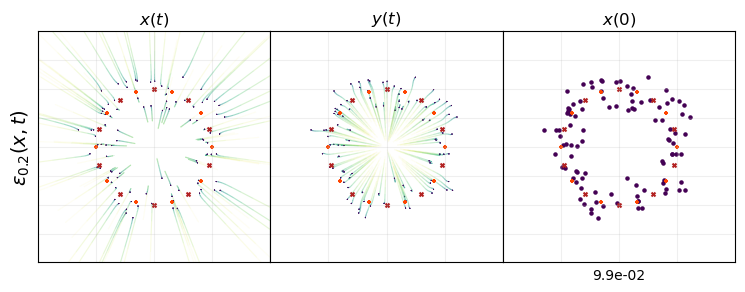

100%|██████████| 40/40 [00:00<00:00, 4672.41it/s]


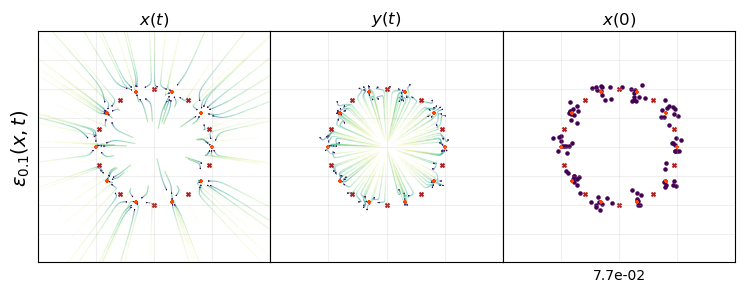

100%|██████████| 40/40 [00:00<00:00, 4603.56it/s]


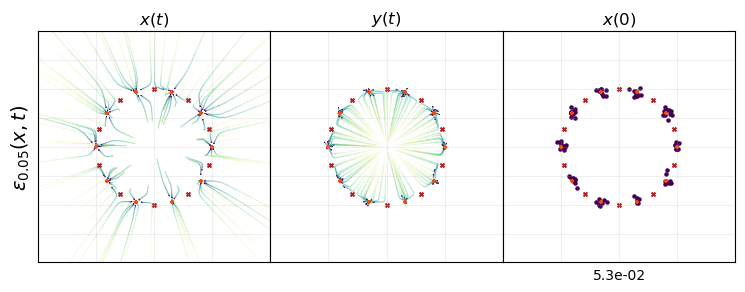

In [95]:
random_data = False
data_str, all_deltas, sigma_idx, N, data, data_labels, data_split = prepare_data(random_data)

scale = 1
data = data * scale
window_size = 2 * scale
all_deltas = all_deltas * scale

# Sampler settings 
dim = data.shape[1]
num_steps, sigma_min, sigma_max, rho = 40, 2e-3, 80, 7  # Number of steps, min noise level, max noise level, sampler curvature

all_deltas = [2e-1, 1e-1, 5e-2]
for i, delta in enumerate(all_deltas):
    # Toy Model settings
    model = ToyModel(data=data[data_split], 
                     data_labels=data_labels[data_split], 
                     num_steps=num_steps, 
                     sigma_min=sigma_min, 
                     sigma_max=sigma_max, 
                     rho=rho, 
                     model_kwargs={'delta': delta, 'cond': False},  # positive network
                     heun=False)
    
    # Simulate and plot
    out = simulate_trajectories(model=model, 
                                x_labels=None,                     # CLass labels for trajectories, None = random
                                n=100,                             # number of trajectories
                                m=100,                             # how many to plot
                                init='random',                     # Initialization mode, 'random' or 'sphere'
                                delta=delta,                       # For ylabel
                                data=data,
                                data_split=data_split,
                                window_size=window_size,
                                full_row=True,
                                save_as=None)                      # Path to save png in
    
del num_steps, sigma_min, sigma_max, rho, model, out

## Toy diffusion model for noise-dependent overfitting
$\newcommand{\e}{\boldsymbol{\varepsilon}}\newcommand{\x}{\boldsymbol{x}}\newcommand{\y}{\boldsymbol{y}}$

We study a 2D toy diffusion model to isolate the mechanism behind the noise-dependent generalization gap observed in real diffusion models under an L2 denoising metric. The goal is not to reproduce image statistics, but to capture the interaction between posterior geometry and noise-dependent dynamics in a controlled, analytically accessible setting.

As data distribution we choose a circle in $\mathbb{R}^2$. This choice has two properties relevant to our analysis:
1. It has no privileged directions and is maximally symmetric, mimicking the isotropy of high-dimensional data distributions.
2. The superposition of samples lies far outside the data manifold, ensuring that posterior averaging produces nontrivial geometric effects.

Training and validation points are sampled i.i.d. from this circle and split evenly.

---

## Posterior mean predictor

Let $\{y_i\}_{i=1}^N$ denote $N$ training samples. We can generate trajectories $\x(t)$ by numerically solving the ordinary differential equation $d\x(t) = \e^*(\x(t), \sigma(t))d\sigma(t)$, with $\e^*$ the optimal noise predictor in the Bayesian sense, and $\sigma(t)\in [0,\sigma_{max}]$ the current noise level. Note that $d\sigma(t)<0$ along a denoising trajectory. [It can be shown](https://arxiv.org/abs/2206.00364) that for a finite set of $N$ data points, the optimal noise predictor takes the explicit form
\begin{equation}
    \e^*(\x, \sigma(t)) = \frac{1}{\sigma(t)} \sum_{i=1}^N (\x-\y_i)p(\y_i|\x,t), \quad p(\y_i|\x,t) = \frac{{\cal N}(\x|\y_i,\sigma(t)^2)}{\sum_{i=1}^N{\cal N}(\x|\y_i,\sigma(t)^2)},
\end{equation}
where ${\cal N}(.|.)$ denotes an isotropic normal distribution. That is, the optimal noise predictor is the normalised residual between $\x$ and the posterior-mean $\sum_{i=1}^N \y_i p(\y_i|\x,t)$ as an estimator for a data point. The optimal noise predictor generates trajectories with endpoints arbitrarily close to one of the data points if the ODE is initialized with $\x_{init}\sim {\cal N}(\x|\textbf{0},\sigma_{max}^2)$ and $\sigma_{max}$ is sufficiently large. 

This defines a smooth vector field over $\mathbb{R}^2$ whose geometry depends on $\tilde{\sigma}$: for small $\tilde{\sigma}$, the predictor is highly localized around individual training points; for large $\tilde{\sigma}$, it becomes global and symmetric.

---

## Modeling an imperfect diffusion model

To construct an error-prone denoiser, we substitute the true data distribution with a “broader” data distribution $P(y) → P_\delta(y)$, with $_\delta(y) = \int_{\mathbb{R}^d} \mathcal{N}(y|y′,δ^2)P(y')dy′$, where $\delta$ is the standard deviation of noise that randomly shifts the true data points. [The corresponding posterior mean predictor is given by](https://arxiv.org/abs/2411.10257)

$$
y_\delta(x,\sigma)
=
\frac{\delta^2 x + \sigma^2\, y^*(x,\tilde{\sigma})}
     {\sigma^2+\delta^2},
\qquad
\tilde{\sigma}^2 = \sigma^2 + \delta^2.
$$

The prediction error decomposes naturally into two factors:

$$
y_\delta(x,\sigma) - x
=
\frac{\sigma^2}{\sigma^2+\delta^2}
\bigl(y^*(x,\tilde{\sigma}) - x\bigr).
$$

This separates:

- **Geometry:**  
  $y^*(x,\tilde{\sigma}) - x$, determined by the arrangement of training points and the scale $\tilde{\sigma}$.

- **Dynamics:**  
  $\frac{\sigma^2}{\sigma^2+\delta^2}$, a scalar that controls how strongly this geometry is expressed.

Note two key properties of this predictor:

1. **Identity-like at now noise:**  
   If $\delta > 0$, as $\sigma \to 0$,
   $$
   y_\delta(x,\sigma) \to x,
   $$

2. **Frozen posterior geometry:**  
The posterior mean is evaluated at noise scale $\tilde{\sigma}$, so even as $\sigma \to 0$, $y^*$ never becomes a projection onto the training points.

<!-- 3. **Error regions around training points:**
The consequence of the above is that the endpoints of randomly sampled trajectories form approximately circular error regions around the training points. The size of these regions is determined by $\delta$. -->

---

## $\sigma$-$\delta$-dependent regimes

**($\sigma \gg \delta$)**  
$y_\delta$ behaves like the posterior mean predictor $y^*$, but $x$ is far away from the data manifold. Resulting corrections tend towards the superposition of the training data, regardless of $y$ being a train or validation sample. Average errors are virtually identical.

**($\sigma \ll \delta$)**  
$y_\delta$ behaves identity-like. Displacement is small everywhere, therefore displacement regions are large and connected, and both training and validation points lie inside them.

**($\sigma \approx \delta$)**  
Corrections are neither suppressed nor far off the manifold. The posterior geometry (flow field) has local structure and its influence is strong enough to matter. 

---

## Interpretation

Crucially, the error parameter $\delta$ determines where in the flow field the transition from $\sigma \gg \delta$ to ($\sigma \ll \delta$) happens, i.e., how localized the flow field structure is. For sufficiently small $\delta$, a generalization gap emerges at $\sigma \approx \delta$, because the denoising update resolves individual training samples strongly enough to exploit their specific locations. For larger $\delta$, the generalization gap is suppressed because the denoising update transitions from global averaging to identity-like behavior without ever entering highly localized regions of the score field.

## Visualizing displacement regions

In order to visualize this effect, we consider regions in space where the model’s displacement magnitude is small relative to the noise level, defined by

$$
\|y_\delta(x,\sigma) - x\| \;\leq\; \sigma.
$$

These regions indicate where the denoising update is dominated by noise-scale effects, such that the predictor behaves similarly on training and validation samples and therefore contributes little to the L2 generalization gap. 

These regions behave differently at different ratios  $\sigma/\delta$.

**($\sigma \gg 1$)**  
Sigma is large, so $\|y_\delta(x,\sigma) - x\|$ only exceeds sigma (i.e. is outside the region) if points are quite far away from the manifold, therefore also far away from validation points -> Validation points lie inside the regions

**($\sigma \ll 1$)**  
For large delta, the predictor is already significantly dampened, reducing prediction magnitude. Therefore, for a prediction to exceed sigma, it's geometry component must compensate and be very large. This only happens far away from training points. As a consequence, depending on the density of points on the manifold, validation points may or may not all lie within the regions. For small delta however, predictions are not dampened and more easily exceed the threshold, when the input is further away form training points than sigma. Therefore, validation points that don't lie close to training points easily fall outside of the regions.

**($\sigma \approx 1$)**  
If delta isn't very small as well, then $y_\delta$ is heavily dampened. In order to lay outside of the region, an input would again need to be very far away from training points, which doesn't happen at low sigma. Therefore, all validation points lay inside the region.

---
